# Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(4)

X = 4*np.random.rand(200, 1)
y = 2 + 3*X + np.random.randn(200, 1)

Agora vamos visualizar os dados no plano cartesiano usando a biblioteca matplotlib.

Text(0, 0.5, 'y')

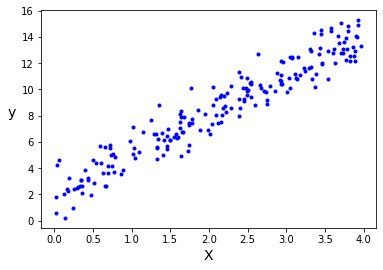

In [3]:
plt.plot(X, y, 'b.')
plt.xlabel('X', fontsize=14)
plt.ylabel('y', rotation = 0, fontsize=14, labelpad=10)

Para começar veremos como os dados se ajustam ao modelo de regressão usando a Equação Normal para obter os parametros.

In [4]:
Xb = np.c_[np.ones(X.shape), X]
theta = np.linalg.inv(Xb.T.dot(Xb)).dot(Xb.T).dot(y)
theta

array([[2.06601206],
       [3.0311673 ]])

A função que usamos para gerar nossos dados foi y = 2 + 3x + ruído. A função prevista é y  ≈2,06 + 3,03x.

Text(0, 0.5, 'y')

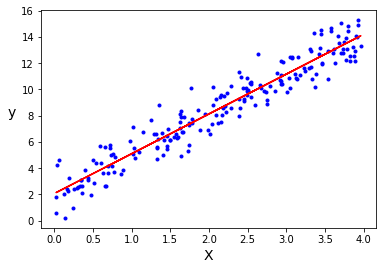

In [5]:
y_pred = Xb.dot(theta)

plt.plot(X, y, 'b.')
plt.plot(X, y_pred, 'r-')
plt.xlabel('X', fontsize=14)
plt.ylabel('y', rotation=0, fontsize=14, labelpad=10)

Usando scikit-learn

In [6]:
from sklearn.linear_model import LinearRegression

Lin_R = LinearRegression()
Lin_R.fit(X, y)

Lin_R.intercept_, Lin_R.coef_

(array([2.06601206]), array([[3.0311673]]))

# Regressão Linear com Gradiente-Descendente
Para realizar a regressão linear com gradiente-descendente usaremos o SGDRegressor do sklearn.

In [7]:
from sklearn.linear_model import SGDRegressor

SGD = SGDRegressor(max_iter=1000, tol=1e-6, eta0=0.01, penalty=None, random_state=7)
SGD.fit(X, np.ravel(y))

y_pred_SGD = SGD.predict(X)

SGD.intercept_, SGD.coef_

(array([1.98674534]), array([3.06206866]))

# Ridge and Lasso Regression

Faremos agora a regressão Ridge usando a solução de forma fechada.

In [8]:
from sklearn.linear_model import Ridge

In [9]:
RidLR = Ridge(solver= 'cholesky', alpha=0.01, random_state=7)
RidLR.fit(X, y)

y_pred_RidLR = RidLR.predict(X)

RidLR.intercept_, RidLR.coef_

(array([2.06625138]), array([[3.03105419]]))

Usando SGDRegressor.

In [10]:
RidSGD = SGDRegressor(max_iter=1000, tol=1e-6, eta0=0.01, penalty='l2', alpha=0.01, random_state=7)
RidSGD.fit(X, np.ravel(y))

y_pred_RidSGD = RidSGD.predict(X)

RidSGD.intercept_, RidSGD.coef_

(array([2.0223134]), array([3.04395243]))

In [11]:
LassoSGD = SGDRegressor(max_iter=10000, tol=1e-6, eta0=0.01, penalty='l1', alpha=0.01, random_state=7)
LassoSGD.fit(X, np.ravel(y))

y_pred_LassoSGD = LassoSGD.predict(X)

LassoSGD.intercept_, LassoSGD.coef_

(array([2.00080499]), array([3.0551296]))

Usando a métrica r-squared 

In [12]:
from sklearn.metrics import r2_score

print('Regression Model \t R2')
print('C-F Linear Regression: \t %2.4f'% r2_score(y, y_pred))
print('SGD Linear Regression: \t %2.4f'% r2_score(y, y_pred_SGD))
print('SGD Ridge Regression: \t %2.4f' % r2_score(y, y_pred_RidSGD))
print('SGD Lasso Regression: \t %2.4f' % r2_score(y, y_pred_LassoSGD))

Regression Model 	 R2
C-F Linear Regression: 	 0.9225
SGD Linear Regression: 	 0.9224
SGD Ridge Regression: 	 0.9225
SGD Lasso Regression: 	 0.9225
